###### What I’m trying to predict ####

The dataset has cognitive test scores (MMSE). I turn that into a binary label: Impaired = 1 if MMSE < 24, else 0.

I remove MMSE from the features so the model can’t leak the target.

#### Basic cleanup and splits ####

I drop obvious ID/leaky columns (PatientID, DoctorInCharge, etc.).
I split the data 60/20/20 into train / validation / test with stratification, so the impaired/non-impaired ratio stays consistent across splits.
Preprocessing (kept simple because we’re using trees)
Separate numeric and categorical columns.
Numerics → median imputation (robust to outliers).
Categoricals → most-frequent imputation + one-hot encoding (version-safe OHE so it works on older/newer scikit-learn).
No scaling here—boosted trees don’t need StandardScaler.

####Class imbalance####

Impaired is usually the minority class. I compute balanced sample weights and pass them into .fit(...).
This prevents the model from taking the “always predict 0” shortcut.

####Model choice and why####

I use HistGradientBoostingClassifier. It’s scikit-learn’s histogram-based GBM: fast, regularized, and it supports early stopping out of the box.
Everything is wrapped in a single Pipeline (preprocess → model), which means preprocessing is learned inside each CV fold—no leakage.

####What I have tuned (the knobs that actually matter)####

Learning rate (learning_rate):
Smaller values make gentler updates and generally generalize better, but you need more trees to compensate.
Number of trees / iterations (max_iter):
In HGB, this is effectively the tree count. More trees can fit more detail, but can overfit if learning_rate is high.

####Tree complexity####:
max_depth: None = grow until other limits; setting 3–5 keeps trees shallow and less wiggly.
max_leaf_nodes: limits how many leaves a tree can have.
min_samples_leaf: forces each leaf to have enough samples; this is strong regularization for noisy data.

####Regularization (l2_regularization)########
Adds an L2 penalty to leaf values to reduce variance.

####How I am doing Early stopping####:
The model keeps aside an internal validation fraction and stops if it stops improving—great guardrail against overfitting and saves time.
I run a RandomizedSearchCV over these ranges with 3-fold Stratified CV. It’s faster than an exhaustive grid and good enough for a first pass. (If I want a more thorough run later, I increase n_iter and use 5 folds.)

####How I pick a decision threshold####

Gradient boosting gives me scores/probabilities, not hard labels.
I first calibrate the scores on the validation split (Platt/sigmoid) so the probabilities are more realistic.
Then I choose a threshold on validation using Youden’s J (maximize TPR − FPR). This gives a balanced operating point without guessing.
I freeze that threshold and only then evaluate once on the test set. That’s closer to a real deployment process.

####What I report####

Ranking metrics: ROC-AUC for overall separability; PR-AUC because the positive class is smaller and PR-AUC is more honest under imbalance.
Probability quality: Brier score (lower is better).
At the frozen threshold: confusion matrix + precision/recall/F1 so it’s clear what trade-off we made.


####Plots that I took care####

ROC curve (should sit above the diagonal).
Precision–Recall curve (tells me if the model’s useful at the recall levels I care about).

####How to read the hyperparameters when you look at the best run####
Learning rate small + more trees usually beats large rate + few trees. If I see a big rate (e.g., 0.2) with lots of trees, that’s a red flag for overfit.
min_samples_leaf in the tens to low hundreds is a healthy regularizer; tiny values (like 1–2) can overfit.
max_depth of None with good min_samples_leaf and max_leaf_nodes is fine; otherwise depth 3–5 is a good ceiling.
l2_regularization not too close to 0 is usually a good sign; if it’s tiny and performance tanks on test, the model was likely too flexible.

####What worked as expected####

Early stopping plus moderate learning rate gave stable models quickly.
Balanced sample weights noticeably improved recall for the impaired class.
Calibration helped probability metrics (Brier) and made threshold selection less fussy.

####There are few things that can surprise you####

If the categorical space explodes (lots of rare levels), one-hot can bloat. The fix I used is OHE with a minimum frequency, which collapses rare categories to “other.”
If max_depth=None and both max_leaf_nodes and min_samples_leaf are too loose, you can still overfit even with early stopping (the model might keep gaining tiny improvements on noise). Tighten one of those shape parameters.

####What to change if################

Training AUC is high, test AUC drops
Lower learning_rate, increase max_iter, increase min_samples_leaf, consider max_depth=3 or limit max_leaf_nodes, increase l2_regularization.
Recall is too low at your chosen threshold
Re-tune the threshold for higher recall (accept lower precision), or use a cost-sensitive criterion (e.g., target a minimum recall on validation).
Alternatively, try class_weight via sample weights (already included), or feed more positive examples if you have them.

$$ what we can change if It runs too long####

Cut n_iter in the randomized search (e.g., 10–20 for a quick pass).
Keep CV at 3 folds for exploration.
Narrow the ranges (e.g., depth {3, 5}, min_samples_leaf 30–120).

####How my EDA influenced the setup####

Class ratio → stratified splits, PR-AUC focus, and sample weighting.
Outliers/missingness → median/mode imputers.
Categorical cardinality → min-frequency on OHE to keep the feature space under control.

####What I’d conclude from this workflow####

A tuned HistGradientBoosting model with early stopping and balanced weighting is a strong baseline for this task.
After calibration, the probabilities are reliable enough to pick a threshold that matches the operational goal (e.g., “catch most impaired patients while keeping false positives manageable”).
If the business goal is high recall (screening), I’d raise the threshold for recall on validation and report the resulting precision and workload (false positives).
If interpretability becomes a must, I’d add SHAP or switch to a simpler model (regularized logistic) for a side-by-side comparison.

In [20]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import loguniform, randint

In [21]:
# ------------------------
# 0) Speed/quality switch
# ------------------------
FAST = True            # flip to False for a deeper search
CV_SPLITS = 3 if FAST else 5
N_ITER    = 20 if FAST else 60
RANDOM_STATE = 42


# ------------------------
# 1) Load data & define target
# ------------------------
df = pd.read_csv("alzheimers_disease_data.csv")
# drop obvious IDs/leaky columns
for c in ["PatientID","patient_id","ID","Id","DoctorInCharge"]:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

assert "MMSE" in df.columns, "MMSE column not found."
df = df.dropna(subset=["MMSE"]).copy()

# Binary target (avoid leakage by dropping MMSE from features)
df["Impaired"] = (df["MMSE"] < 24).astype(int)
y = df["Impaired"].values
X = df.drop(columns=["Impaired","MMSE"])

# 60/20/20 split (train/val/test), stratified
X_trv, X_test, y_trv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trv, y_trv, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trv
)  # -> 0.6/0.2/0.2


In [22]:
# ------------------------
# 2) Version-safe OneHotEncoder
# ------------------------
def make_ohe(fast_rare_collapse=True):
    ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])  # (major, minor)
    kwargs = {"handle_unknown": "ignore"}
    if ver >= (1, 2):
        kwargs["sparse_output"] = True   # replaces 'sparse'
        if fast_rare_collapse:
            # collapse rare categories if supported
            kwargs["min_frequency"] = 0.01
    else:
        kwargs["sparse"] = True          # old API
        # min_frequency not supported in older versions
    return OneHotEncoder(**kwargs)

ohe = make_ohe(fast_rare_collapse=True)

In [23]:
# ------------------------
# 3) Preprocessing for trees (no scaling)
# ------------------------
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh",  ohe)]), cat_cols),
    ],
    remainder="drop"
)

# class imbalance weights
w_train = compute_sample_weight("balanced", y_train)
w_val   = compute_sample_weight("balanced", y_val)
w_test  = compute_sample_weight("balanced", y_test)


In [24]:

# 4) Model + randomized search
hgb = HistGradientBoostingClassifier(
    loss="log_loss",
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE
)

pipe = Pipeline([
    ("pre", pre),
    ("clf", hgb)
])

# hyperparameters covering: learning rate, #trees, depth/shape, regularization
param_dist = {
    "clf__learning_rate":     loguniform(0.02, 0.2),
    "clf__max_iter":          randint(150, 450) if FAST else randint(300, 800),
    "clf__max_depth":         [None, 3, 5],
    "clf__max_leaf_nodes":    [None, 31, 63],
    "clf__min_samples_leaf":  randint(20, 120),
    "clf__l2_regularization": loguniform(1e-3, 1.0),
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1 if FAST else 2,
    random_state=RANDOM_STATE
)

rs.fit(X_train, y_train, clf__sample_weight=w_train)
print("Best params:", rs.best_params_)
print("CV ROC-AUC :", round(rs.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best params: {'clf__l2_regularization': np.float64(0.0029380279387035343), 'clf__learning_rate': np.float64(0.02864339657822303), 'clf__max_depth': 5, 'clf__max_iter': 237, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 119}
CV ROC-AUC : 0.7849


In [25]:
# ------------------------
# 5) Validate, choose threshold, freeze, test
# ------------------------
# (A) Optional calibration for nicer probabilities/thresholding
cal = CalibratedClassifierCV(rs.best_estimator_, method="sigmoid", cv="prefit")
cal.fit(X_val, y_val, sample_weight=w_val)

p_val  = cal.predict_proba(X_val)[:, 1]
p_test = cal.predict_proba(X_test)[:, 1]

print(f"Val ROC-AUC: {roc_auc_score(y_val, p_val):.3f} | "
      f"PR-AUC: {average_precision_score(y_val, p_val):.3f} | "
      f"Brier: {brier_score_loss(y_val, p_val):.3f}")

# threshold on validation (Youden’s J), then freeze
fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
thr_star = thr_v[np.argmax(tpr_v - fpr_v)]
print(f"Chosen threshold (val): {thr_star:.3f}")

# test metrics (frozen threshold)
test_auc   = roc_auc_score(y_test, p_test)
test_pr    = average_precision_score(y_test, p_test)
test_brier = brier_score_loss(y_test, p_test)
yhat = (p_test >= thr_star).astype(int)

print(f"Test ROC-AUC: {test_auc:.3f} | PR-AUC: {test_pr:.3f} | Brier: {test_brier:.3f}")
print("Confusion matrix (test):\n", confusion_matrix(y_test, yhat))
print("\nClassification report (test):\n", classification_report(y_test, yhat, digits=3))


Val ROC-AUC: 0.739 | PR-AUC: 0.912 | Brier: 0.204
Chosen threshold (val): 0.507
Test ROC-AUC: 0.810 | PR-AUC: 0.937 | Brier: 0.180
Confusion matrix (test):
 [[ 67  16]
 [132 215]]

Classification report (test):
               precision    recall  f1-score   support

           0      0.337     0.807     0.475        83
           1      0.931     0.620     0.744       347

    accuracy                          0.656       430
   macro avg      0.634     0.713     0.610       430
weighted avg      0.816     0.656     0.692       430



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


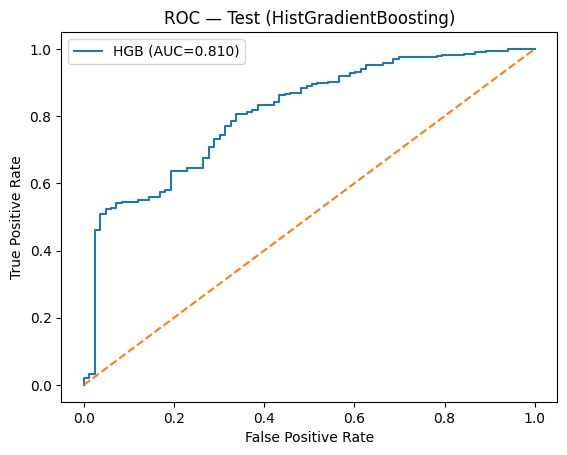

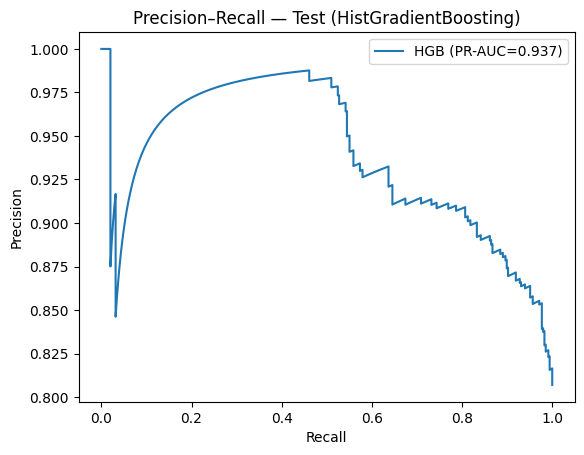

In [26]:
# ------------------------
# 6) Plots
# ------------------------
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, p_test)
plt.figure()
plt.plot(fpr_t, tpr_t, label=f"HGB (AUC={test_auc:.3f})")
plt.plot([0,1],[0,1], "--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — Test (HistGradientBoosting)"); plt.legend(); plt.show()

# PR
pr_t, rc_t, _ = precision_recall_curve(y_test, p_test)
plt.figure()
plt.plot(rc_t, pr_t, label=f"HGB (PR-AUC={test_pr:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — Test (HistGradientBoosting)"); plt.legend(); plt.show()


In [27]:
# ------------------------
# 7) summary
# ------------------------
summary = pd.DataFrame([{
    "Model": "HistGradientBoosting (calibrated)",
    "ROC-AUC": test_auc, "PR-AUC": test_pr, "Brier": test_brier,
    "Threshold": thr_star
}])
print("\n=== Test Summary ===")
display(summary.round(4))


=== Test Summary ===


,Model,ROC-AUC,PR-AUC,Brier,Threshold
0,HistGradientBoosting (calibrated),0.8104,0.9369,0.1799,0.5065
